# Core Community Survey Simulations

***

## Kernel Information and Read-Only Status

To run this notebook, please select "Roman Research Nexus {VERSION}" kernel at the top right of your window. For example "Roman Research Nexus 2026.1". 

This notebook is read-only. You can run cells and make edits, but you must save changes to a different location. We recommend saving the notebook within your home directory, or to a new folder within your home (e.g. <span style="font-variant:small-caps;">file > save notebook as > my-nbs/nb.ipynb</span>). Note that a directory must exist before you attempt to add a notebook to it.

## Introduction

The Roman Science Operations Center (SOC) has created a suite of simulated data products based on downscaled versions of the Roman Core Community Survey (CCS) programs. The goal of these simulated products was primarily to test the SOC data pipelines and, potentially, other mission pipelines at a scale similar to that expected during science operations. As such, these simulations provide sufficient scientific fidelity to test the SOC pipelines and do not necessarily include everything that may be observed on-orbit. Specifically, the simulations **do not include time-variable sources.** More details on what is included in the simulations are provided in the descriptions of each simulation set below.

Note that we have only simulated the three CCS programs, and even then, only subsets of these programs. We have neither included the Galactic Plane Survey (GPS), which, despite being community-defined, is not a CCS program, nor any General Astrophysics Survey (GAS) example programs in the simulations.

These simulated data products were generated by creating Level 1 (L1) uncalibrated ramps with Roman I-Sim, and then processing those L1 products through the Exposure Level Pipeline to produce Level 2 (L2) calibrated rate images. For the High-Latitude Wide-Area Survey (HLWAS), the L2 products were further processed with the Mosaic Pipeline to create Level 3 (L3) co-added mosaic images.

In this tutorial, in addition to documentation about the simulations, we provide manifest files of the simulation products stored on AWS S3 and show how to perform searches (i.e., cone searches, metadata searches) and retrieve the data from AWS S3. 

In this tutorial, you will:
- Learn how to search for and retrieve SOC simulated data products for the High-Latitude Wide-Area and Galactic Bulge Time-Domain Surveys
- Access input catalogs for the simulations
- Work with simulated products including visualizations and catalog data
- Correct the Galactic Bulge simulation WCS

**If you want to skip the simulation descriptions and other information,** you can also go directly to [Data Access and Examples](#data_access).

## Imports

- *astropy.coordinates* - For celestial coordinate operations.
- *astropy_healpix* - For working with HEALPixels.
- *astropy.io* - For accessing FITS tables.
- *astropy.table* - For reading manifest files.
- *astropy.time* - For working with time objects.
- *astropy.visualization* - For normalizing images for display.
- *astropy.units* - For unit operations.
- *fix_gbtds_wcs* - For updating GBTDS simulation World Coordinate System objects.
- *healpy* - For working with HEALPixels.
- *matplotlib.pyplot* - For plotting images.
- *numpy* - For array operations.
- *os* - For working with paths.
- *romancal.step* - For access Roman science data pipeline processing steps.
- *roman_datamodels* - For opening Roman WFI data products.
- *s3fs* - For connecting to an AWS S3 bucket and streaming files into memory.

In [1]:
%matplotlib inline
from astropy.coordinates import SkyCoord, Galactic
from astropy_healpix import HEALPix
from astropy.io import fits
from astropy.table import Table
from astropy.time import Time, TimeDelta
from astropy.visualization import simple_norm
from astropy import units as u
from fix_gbtds_wcs import update_wcs
import healpy as hpy
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pyarrow as pa
import roman_datamodels as rdm
import romancal.step
import s3fs

***

## Galactic Bulge Time-Domain Survey (GBTDS)

### Simulation Program Design

The GBTDS simulation was designed primarily to test SOC data processing performance requirements at the scale expected to support on-orbit GBTDS observations. To this end, we simulated approximately one week (7.8 days) of typical GBTDS observations, i.e.:

1. F146 observations every ~12.1 minutes;
2. F087 and F213 observations every ~12 hours;
3. and a series of snapshot observations in F062, F106, F219, F158, and F184.

The simulation APT program was designed to mimic the on-orbit implementation of the GBTDS at the time the simulations were run (approximately February 2026). This includes standard subpixel dither patterns for the snapshot observations (i.e., the subpixel patterns were selected from the options in APT) and custom subpixel dither patterns using mosaic patterns for the timeseries observations. The footprint of the GBTDS simulation is shown in Figure 1 below:

<center>
    <div style="width: 70%">
        <img src="gbtds_footprint.png" width="80%" height="auto"> </ br>
        <b>Figure 1:</b> Footprint of the GBTDS Simulation. Each color shown corresponds to a single pointing of the WFI. The GBTDS simulation uses the fall season mosaic pattern with six fields: five in a strip along the Galactic plane and a single field overlapping the Galactic Center. The axes show Galactic coordinates (longitude on the X-axis and latitude on the Y-axis) in units of degrees.
    </div>
</center>

### Input Catalog

The input catalog for the GBTDS simulation was created using the population synthesis code [Synthpop](https://synthpop.readthedocs.io/en/latest/) (version 1.0.4; [Klüter et al. 2025](https://ui.adsabs.harvard.edu/abs/2025AJ....169..317K/abstract)). Note that we simulated only point sources and no extended sources for the GBTDS simulation, though it is expected there will be extended sources visible in the real GBTDS data. We used [PARSEC](https://stev.oapd.inaf.it/cgi-bin/cmd) isochrones updated to the March 2024 Roman WFI filter throughput curves. For each imaging filter, we averaged the throughput curves from each of the 18 WFI detectors into an average filter throughput curve to reduce the complexity of the simulation inputs, i.e., rather than different input catalogs per detector each containing all sources, a single input catalog could be used for sources on any detector. We set the limiting magnitude of the population synthesis to be $m_{\mathrm{F146}} = 26.4$ AB magnitudes, which corresponds to a signal-to-noise ratio S/N = 1 in a single exposure.

The input catalog was broken down into HEALPixels ([Górski et al. 2004](https://iopscience.iop.org/article/10.1086/427976/pdf)) with $n_{\mathrm{side}} = 512$ and saved as FITS tables for input into Roman I-Sim. With a value of $n_{\mathrm{side}} = 512$, HEALPixels are approximately the same size (6.9 arcminutes on a side) to individual WFI detectors (7.5 arcminutes on a side). Note that to conform to Roman I-Sim expectations, the HEALPixels were defined in Galactic Coordinates using the NESTED ordering scheme, with filenames of the input catalogs like `{HEALPixel_ID}-cat.fits`. We generated input catalogs for all HEALPixels that partially touched a WFI detector using the pointing information from the APT program of the simulation, and, to be sure there was contiguous coverage of the simulation footprint, we grew the list of HEALPixels by one in all directions. Figure 2 shows the number of sources per HEALPixel in the GBTDS simulation:

<center>
    <div style="width: 70%">
        <img src="gbtds_healpix_count.png" width="80%" height="auto"> </ br>
        <b>Figure 2:</b> Number of simulated point sources per HEALPixel in the GBTDS simulation footprint. The axes are the same as in Figure 1. The colorbar uses a log scale such that the numbers correspond to log<sub>10</sub><i>(N)</i>, where <i>N</i> is the number of point sources in a HEALPixel tile. The HEALPixels use an <i>n</i><sub>side</sub> value of 512. The axes show Galactic coordinates (longitude on the X-axis and latitude on the Y-axis) in units of degrees.
    </div>
</center><br />

The number of sources ranged from 3.5 – 13.2 million stars per HEALPixel. In addition to creating a realistic mix of spectral types and luminosity classes within the GBTDS footprint, the simulation also included dust reddening and extinction, as well as star clustering. Several artifacts are present in the input catalog, such as large-scale (~100-pixel) features related to the dust map resolution and simple assumptions used by Synthpop; however, these are not expected to affect pipeline testing and are likely only cosmetic.

<a id="gbtds_caveats"></a>
### Simulation Settings and Caveats

The GBTDS simulation used the following major package versions in the SOC Data Management Subsystem (DMS) High-Level Processing Partition (HLPP) TEST environment:

| Package Name | Version |
| :--- | ---: |
| romanisim | 0.12.0 |
| romancal | 0.22.0 |
| roman_datamodels | 0.29.1 |
| rad | 0.29.1 |

The Calibration Reference Data System (CRDS) context was set to `roman_0043.pmap`.

Note that the quality of the reference files impacts the quality of the simulated data. At the time the simulation was run, the reference files were still being updated and were largely based on older ground-based test data, or in some cases they were placeholders (such as the dark rate).

Roman I-Sim version 0.12.0 was released to improve the performance of point source simulations and did not simulate dark decay, integral non-linearity (INL), or WFI18 high-amplitude transient effects, which were identified in WFI thermal vacuum (TVAC) data. However, RomanCal version 0.22.0, which is required to process L1 products generated by Roman I-Sim 0.12.0, does include corrections for dark decay, INL, and the WFI18 transient effects. Therefore, the simulated GBTDS Level 2 (L2) calibrated rate images are ***overcorrected*** for these effects. To summarize the impacts:

1. Dark decay produces an exponential decline in the number of counts, with an amplitude of 0.1 – 0.7 DN, over the first several reads (approximately 20 – 35 seconds) of a WFI ramp. The exact amplitude and duration are unique to each WFI detector. See [Betti et al. (2025)](https://www.stsci.edu/files/live/sites/www/files/home/roman/documentation/technical-documentation/_documents/Roman-STScI-000814.pdf) for more information.
2. INL is a readout-channel-dependent effect that produces a time-dependent pedestal offset. This creates vertical striping effects visible in the rate images, particularly in sky-dominated scenes. The amplitude of the effect is ~10 DN. See [Brandt & Thushara (2025)](https://www.stsci.edu/files/live/sites/www/files/home/roman/documentation/technical-documentation/_documents/Roman-STScI%e2%80%93000866.pdf) for more information.
3. The WFI18 high-amplitude transient is only observed in the WFI18 detector. In the first read of a ramp, WFI18 exhibits a vertical gradient of counts, the absolute value of which decreases in the direction away from the slow readout register. The gradient is best represented as the sum of two exponential functions, with an amplitude of ~100 DN. See [Brandt (2025)](https://www.stsci.edu/files/live/sites/www/files/home/roman/documentation/technical-documentation/_documents/Roman-STScI-000867.pdf) for more information.

<div class="alert alert-warning" style="color:black; background-color:#FFF1AD; border-color:orange;">
    <b>Warning:</b> After creation of the L2 products, an important issue with the World Coordinate System (WCS) was discovered. An example fix is provided below in [Correcting GBTDS Simulation WCS](). After <i>Gaia</i> alignment, the GBTDS WCS randomly drifts by up to a couple tens of arcseconds. It is not clear at present if this is because of the crowded nature of the scene (and thus potential mismatches with the <i>Gaia</i> astrometric catalog), the lack of real <i>Gaia</i> stars in the simulation, a combination of these two issues, or another cause. Investigations are underway to prevent this from happening to the executed GBTDS program (and any other crowded fields) on-sky and will be tested during the commissioning period after launch.
</div>

### Simulated Products

<center>
    <div style="width: 70%">
        <img src="gbtds_color.png" width="60%" height="auto"> </ br>
        <b>Figure 3:</b> A three-color image of a single WFI detector in the GBTDS simulation.
    </div>
</center><br />

For more information about SOC data products, please see the RDox article [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products). For the GBTDS simulation, the SOC has produced L1 and L2 data products, which include:

- Uncalibrated L1 ramp cubes in units of DN (`*_uncal.asdf`)
- Calibrated L2 rate images in units of DN/s (`_cal.asdf`)
- Preview and thumbnail images of L2 products in PNG format (`_preview.png` and `*_thumb.png`, respectively)
- L1 updated WCS based on L2 *Gaia* alignment (`*_wcs.asdf`)

On-sky GBTDS products generated by the SOC and available via MAST will also include parquet source catalog files for each individual exposure and an associated segmentation map. These products were not stored on AWS S3 after the GBTDS simulation run, however we have provided instructions below in [Making GBTDS L4 Products](#making_catalogs) for creating these files yourself from the L2 files on S3, and have provided a small sample of a few files for those interested in example files.

The SOC does not plan to produce Level 3 (L3) mosaic products or any data release (DR) products for the GBTDS; rather, these products will be produced by the SSC and will likewise be available via MAST. Note that the L4 products produced by the SOC are not optimized at-present for crowded fields and will therefore be incomplete. Prompt L4 source catalogs derived from L2 products are primarily intended to be used as part of the alignment of data products with the <i>Gaia</i> astrometric catalog, and while in some cases they may be useful for science, that is not their primary intended purpose.

### Data Organization on S3

GBTDS L1 and L2 science data products are available via the STScI AWS Open Data Bucket S3 bucket located at `s3://stpubdata/roman/nexus/soc_simulations/r00340/`. The string `r00340` in the URI refers to the program ID of the simulation, i.e., program ID 340. There are subdirectories `l1/` and `l2/` for L1 and L2 data products, respectively. Please see the [Data Access Example](#data_access) below for instructions on how to stream the files into memory on the Nexus.

## High-Latitude Wide-Area Survey (HLWAS)

### Simulation Program Design

The SOC HLWAS simulation is designed primarily to provide a realistic representation of the tiered survey design, dither pattern, and depth expected form the on-orbit HLWAS observations, yielding data products suitable for testing SOC data release processing and nominal non-GBTDS data processing rates. To accomplish this, we have simulated approximately 6 square degrees of the HLWAS, comprising the Wide, Medium, Deep, and Ultra-Deep Tiers, using the APT program's survey design as of February 2026.

The simulation is somewhat simplified compare to the expected on-orbit execution in two important ways:

1. We chose to co-locate all of the tiers on the sky, which reduces slew times.
2. We run all exposures consecutively in the simulation, whereas the on-orbit execution will include pauses for calibrations and non-HLWAS science observations.

The SOC simulations only encompass the WFI imaging mode and do not include simulations of the grism observations. Figure 3 below shows the footprint of the HLWAS simulation.

<center>
    <div style="width: 70%">
        <img src="hlwas_footprint.png" width="80%" height="auto"> </ br>
        <b>Figure 4:</b> Footprint of the HLWAS Simulation. This shows only the first exposure per visit in one pass of the HLWAS and does not show the dither patterns or multiple passes overlaid. Each color corresponds to one pointing of the WFI. The axes show Celestial coordinates (right ascension on the X-axis and declination on the Y-axis) in units of degrees.
    </div>
</center>

### Input Catalog

The input catalog for the HLWAS simulation is the same as that used for the OpenUnivers2024 simulation ([OpenUniverse et al. 2025](https://ui.adsabs.harvard.edu/abs/arXiv:2501.05632)). We updated the catalog to use the latest WFI photometric bandpass information available as of March 2024, which is located in the [Roman Technical Information](https://github.com/RomanSpaceTelescope/roman-technical-information/) respository. As we do not know <i>a priori</i> which detector any particular source will land on during input catalog creation, we used an average bandpass, which was the arithmetic mean of the 18 WFI detector bandpasses.

Also note that Roman I-Sim expects galaxies to be represented as single Sérsic profiles; however, OpenUniverse represents galaxies as double Sérsic profiles to better model the bulge and disk components. We handled this by inputting two single Sérsic models at each OpenUniverse galaxy position with the same position angle.

The final input catalog for the HLWAS simulation includes:
- OpenUniverse galaxies
- OpenUniverse Milky Way faint stars
- <i>Gaia</i> Data Release 2 (DR2) stars

Time variable transients were not included in the images simulated by the SOC.

### Simulation Settings and Caveats

The HLWAS simulation used the following major package versions in the SOC Data Management Subsystem (DMS) High-Level Processing Partition (HLPP) TEST environment:

| Package Name | Version |
| :--- | ---: |
| romanisim | 0.13.1 |
| romancal | 0.23.0.dev3+g382e89284 |
| roman_datamodels | 0.30.0 |
| rad | 0.30.0 |

Additionally, prompt L3 products (and their associated L4 products) were made in the SOC I&T environment.

The CRDS context was set to `roman_0046.pmap`.

The effects discussed in the GBTDS simulation are now simulated and corrected for in the HLWAS simulated data. However, as mentioned with the GBTDS, the quality of the reference files impacts the quality of the simulated data. At the time the simulation was run, the reference files were still being updated and effects like INL were still present in the reference files themselves. Additionally, the reference files were based on older ground-based test data, or in some cases they were placeholders (such as the dark rate).

### Simulated Products

For more information about SOC data products, please see the RDox article [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products). For the HLWAS simulation, the SOC has produced L1, L2, L3, and L4 data products, which include:

- Uncalibrated L1 ramp cubes in units of DN (`*_uncal.asdf`)
- Calibrated L2 rate images in units of DN/s (`_cal.asdf`)
- Preview and thumbnail images of L2 and L3 products in PNG format (`_preview.png` and `*_thumb.png`, respectively)
- L1 updated WCS based on L2 *Gaia* alignment (`*_wcs.asdf`)
- Co-added L3 mosaic images in units of MJy/sr (`_coadd.asdf`)
- L4 source catalogs made from both L2 and L3 inputs (`_cat.parquet`)
- L4 segmentation maps made from both L2 and L3 inputs (`_segm.asdf`)

### Data Organization on S3

HLWAS science data products are available via the STScI AWS Open Data Bucket S3 bucket located at `s3://stpubdata/roman/nexus/soc_simulations/r00342/`. The string `r00342` in the URI refers to the program ID of the simulation, i.e., program ID 342. There are subdirectories `l1/`, `l2/`, `l3/`, and `l4/` for L1, L2, L3, and L4 data products, respectively. Under the `l4/` directory, there are additional subdirectories for different product types and different inputs to the L4 processing:
- `l2_segmentation_map/` - Segmentation maps made from L2 files
- `l2_source_catalog/` - Source catalogs made from L2 files
- `l3_segmentation_map/` - Segmentation maps made from L3 files
- `l3_source_catalog/` - Source catalogs made from L3 files

Please see the [Data Access Example](#data_access) below for instructions on how to stream the files into memory on the Nexus.

<a id="data_access"></a>
## Data Access and Examples

All the SOC simulation data is available via AWS S3 and can be streamed directly into memory without the need to copy files to local storage. More information on file streaming and, if necessary, copying files locally can be found in the [Data Discovery and Access](../data_discovery_and_access/data_discovery_and_access.ipynb) tutorial.

<div class="alert alert-warning" style="color:black; background-color:#ADE3FF; border-color:blue;">
    <b>Note:</b> You may see warnings when reading the simulated ASDF files due to the files being created with older versions of SOC Python packages. These warnings are benign and can be safely ignored.
</div>

### Searching for Data in the Simulation

The simulated GBTDS and HLWAS files are available via the STScI AWS S3 Open Data Bucket at `s3://stpubdata/roman/nexus/soc_simulations/` with subdirectories for each simulation program (`r00340` and `r00342` for GBTDS and HLWAS, respectively). Files are organized in subdirectories according to data product level (e.g., `l1/`, `l2/`, etc.) beneath the program directories.

Manifest files in the form of Enhanced Comma-Separated Values (or ECSV) files have been provided that include common metadata that users may be interested in searching over. The [ECSV format](https://docs.astropy.org/en/stable/io/ascii/ecsv.html) is an astropy-supported, human-readable form for storing tabular data. These files are meant as a replacement for searching for data via the MAST website or using `astroquery`, as these data have not been ingested into the MAST database. The on-sky GBTDS and HLWAS data will be searchable using standard tools.

The manifest files for the GBTDS and HLWAS are slightly different from each other, so let's take a look at what is in each of them first. The files for the L1 and L2 data products are called `hlwas_manifest.ecsv` and `gbtds_manifest.ecsv`. For L3 products, there is also the `hlwas_manifest_l3.ecsv` file. Let's start by looking at the GBTDS manifest (note that for display purposes, we have limited the length of the tables returned in several of the following cells):

In [2]:
gbtds_manifest = Table.read('gbtds_manifest.ecsv')
gbtds_manifest[:5]

wfi_ra,wfi_dec,wfi_pa,detector_ra,detector_dec,detector,optical_element,start_time,end_time,ma_table_id,exptime,pass,segment,observation,visit,exposure,l1_s3_uri,l2_s3_uri
float64,float64,float64,float64,float64,str5,str4,str23,str23,str7,float64,int64,int64,int64,int64,int64,str100,str98
268.536419,-28.539441,90.46325045085938,268.11703729056586,-28.493460496328897,WFI09,F146,2027-10-07T01:23:41.000,2027-10-07T01:24:47.412,SCI1002,66.41188,4,1,25,17,1,s3://stpubdata/roman/nexus/soc_simulations/r00340/l1/r0034001004001025017_0001_wfi09_f146_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00340/l2/r0034001004001025017_0001_wfi09_f146_cal.asdf
268.536419,-28.539441,90.46325045085938,268.62345470431995,-28.54325724446787,WFI10,F146,2027-10-07T01:23:41.000,2027-10-07T01:24:47.412,SCI1002,66.41188,4,1,25,17,1,s3://stpubdata/roman/nexus/soc_simulations/r00340/l1/r0034001004001025017_0001_wfi10_f146_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00340/l2/r0034001004001025017_0001_wfi10_f146_cal.asdf
268.536419,-28.539441,90.46325045085938,268.5386277436867,-28.669287699140966,WFI11,F146,2027-10-07T01:23:41.000,2027-10-07T01:24:47.412,SCI1002,66.41188,4,1,25,17,1,s3://stpubdata/roman/nexus/soc_simulations/r00340/l1/r0034001004001025017_0001_wfi11_f146_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00340/l2/r0034001004001025017_0001_wfi11_f146_cal.asdf
268.536419,-28.539441,90.46325045085938,268.46251237089393,-28.781912869029355,WFI12,F146,2027-10-07T01:23:41.000,2027-10-07T01:24:47.412,SCI1002,66.41188,4,1,25,17,1,s3://stpubdata/roman/nexus/soc_simulations/r00340/l1/r0034001004001025017_0001_wfi12_f146_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00340/l2/r0034001004001025017_0001_wfi12_f146_cal.asdf
268.536419,-28.539441,90.46325045085938,268.7722043115358,-28.58882204389884,WFI13,F146,2027-10-07T01:23:41.000,2027-10-07T01:24:47.412,SCI1002,66.41188,4,1,25,17,1,s3://stpubdata/roman/nexus/soc_simulations/r00340/l1/r0034001004001025017_0001_wfi13_f146_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00340/l2/r0034001004001025017_0001_wfi13_f146_cal.asdf


We can also examine the column names without having to scroll:

In [3]:
print(f'Column names for GBTDS: {gbtds_manifest.columns}')

Column names for GBTDS: <TableColumns names=('wfi_ra','wfi_dec','wfi_pa','detector_ra','detector_dec','detector','optical_element','start_time','end_time','ma_table_id','exptime','pass','segment','observation','visit','exposure','l1_s3_uri','l2_s3_uri')>


Next we check the number of entries in the table. Each entry corresponds to one dataset. Each exposure contains 18 datasets for L1 and L2 because each detector is stored as a separate dataset.

In [4]:
len(gbtds_manifest)

88038

We see there are 88,038 rows in the table, which means there are 88,038 datasets of L1 and L2 science data products for the GBTDS simulation. This corresponds to 4,891 WFI exposures.

And next we examine the HLWAS manifest:

In [5]:
hlwas_manifest = Table.read('hlwas_manifest.ecsv')
hlwas_manifest[:5]

wfi_ra,wfi_dec,wfi_pa,detector_ra,detector_dec,detector,optical_element,start_time,end_time,ma_table_id,exptime,pass,segment,observation,visit,exposure,l1_s3_uri,l2_s3_uri
float64,float64,float64,float64,float64,str5,str4,str23,str23,str7,float64,int64,int64,int64,int64,int64,str100,str98
8.096021,-43.708709,0.40705870754605994,8.493435848846008,-43.639085407254484,WFI15,F129,2027-07-13T12:59:05.000,2027-07-13T13:03:59.110,SCI1018,294.10974,10,1,5,7,3,s3://stpubdata/roman/nexus/soc_simulations/r00342/l1/r0034201010001005007_0003_wfi15_f129_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201010001005007_0003_wfi15_f129_cal.asdf
8.096021,-43.708709,0.40705870754605994,8.176113989684378,-43.351063056910796,WFI16,F129,2027-07-13T12:59:05.000,2027-07-13T13:03:59.110,SCI1018,294.10974,10,1,5,7,3,s3://stpubdata/roman/nexus/soc_simulations/r00342/l1/r0034201010001005007_0003_wfi16_f129_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201010001005007_0003_wfi16_f129_cal.asdf
8.096021,-43.708709,0.40705870754605994,8.352270597712408,-43.42424897282728,WFI17,F129,2027-07-13T12:59:05.000,2027-07-13T13:03:59.110,SCI1018,294.10974,10,1,5,7,3,s3://stpubdata/roman/nexus/soc_simulations/r00342/l1/r0034201010001005007_0003_wfi17_f129_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201010001005007_0003_wfi17_f129_cal.asdf
8.096021,-43.708709,0.40705870754605994,8.50795044599109,-43.48760128008559,WFI18,F129,2027-07-13T12:59:05.000,2027-07-13T13:03:59.110,SCI1018,294.10974,10,1,5,7,3,s3://stpubdata/roman/nexus/soc_simulations/r00342/l1/r0034201010001005007_0003_wfi18_f129_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201010001005007_0003_wfi18_f129_cal.asdf
8.272501,-43.69404,0.40685003174550194,8.182759214809003,-43.73511443610071,WFI01,F129,2027-07-13T13:05:25.000,2027-07-13T13:10:19.110,SCI1018,294.10974,10,1,5,8,1,s3://stpubdata/roman/nexus/soc_simulations/r00342/l1/r0034201010001005008_0001_wfi01_f129_uncal.asdf,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201010001005008_0001_wfi01_f129_cal.asdf


and the list of column names:

In [6]:
print(f'Column names for HLWAS: {hlwas_manifest.columns}')

Column names for HLWAS: <TableColumns names=('wfi_ra','wfi_dec','wfi_pa','detector_ra','detector_dec','detector','optical_element','start_time','end_time','ma_table_id','exptime','pass','segment','observation','visit','exposure','l1_s3_uri','l2_s3_uri')>


Let's see how many entries there are in the HLWAS table:

In [7]:
len(hlwas_manifest)

68040

There are 68,040 datasets in the HLWAS simulation, composing 3,780 WFI exposures.

Briefly, let's define the column names in the manifest files:

- **wfi_ra** and **wfi_dec**: The right ascension and declination of the WFI center (i.e., the target position for the focal plane) in degrees. These correspond to `meta.pointing.target_ra` and `target_dec` in the ASDF files.
- **wfi_pa**: The position angle of the V3 axis with respect to Celestial North, increasing to the East, in units of degrees. This corresponds to `meta.pointing.pa_v3` in the ASDF files.
- **detector_ra** and **detector_dec**: The right ascension and declination of the detector center in degrees. This corresponds to `meta.wcs_info.ra_ref` and `dec_ref` in the ASDF files.
- **detector**: The WFI detector name. This corresponds to `meta.instrument.detector` in the ASDF files.
- **optical_element**: The name of the WFI optical element. This corresponds to `meta.instrument.optical_element` in the ASDF files.
- **start_time**: The simulated start time of the exposure. This corresponds to `meta.exposure.start_time` in the ASDF files.
- **end_time**: The simulated end time of the exposure. This corresponds to `meta.exposure.end_time` in the ASDF files.
- **ma_table_id**: The identifier of the multi-accumulation table used for the exposure. This corresponds to `meta.exposure.ma_table_id` in the ASDF files.
- **exptime**: The exposure time in seconds. This corresponds to `meta.exposure.exposure_time` in the ASDF files.
- **pass**: The programmatic pass number. See the RDox [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Table-L1L2-ComponentsTableofL1andL2RootNameComponents) article for more information.
- **segment**: The programmatic segment number. See the RDox [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Table-L1L2-ComponentsTableofL1andL2RootNameComponents) article for more information.
- **observation**: The programmatic observation number. See the RDox [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Table-L1L2-ComponentsTableofL1andL2RootNameComponents) article for more information.
- **visit**: The programmatic visit number. See the RDox [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Table-L1L2-ComponentsTableofL1andL2RootNameComponents) article for more information.
- **exposure**: The programmatic exposure number. See the RDox [WFI Data Levels and Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products#WFIDataLevelsandProducts-Table-L1L2-ComponentsTableofL1andL2RootNameComponents) article for more information.
- **l1_s3_uri**: The S3 URI for the primary L1 science data product.
- **l2_s3_uri**: The S3 URI for the primary L2 science data product.

There is also a file called `hlwas_coadd_manifest.ecsv`, which contains a different set of columns for the Level 3 (L3) mosaic co-added data products for the HLWAS simulation. Let's take a look at that now:

In [8]:
hlwas_coadd_manifest = Table.read('hlwas_coadd_manifest.ecsv')
hlwas_coadd_manifest[:5]

skycell_ra,skycell_dec,skycell_name,grouping,exptime,max_exptime,optical_element,l3_s3_uri
float64,float64,str12,str15,float64,float64,str4,str106
8.975205942985813,-43.26800876245513,010m42x30y36,v01001001004017,732.3993542471724,882.3294067382812,F146,s3://stpubdata/roman/nexus/soc_simulations/r00342/l3/r00342_p_v01001001004017_010m42x30y36_f146_coadd.asdf
9.075841684845507,-43.26920037831668,010m42x30y37,v01001001004017,580.6951878954015,882.3294067382812,F146,s3://stpubdata/roman/nexus/soc_simulations/r00342/l3/r00342_p_v01001001004017_010m42x30y37_f146_coadd.asdf
9.176485503959354,-43.270303817567495,010m42x30y38,v01001001004017,471.4548931902129,588.2196044921875,F146,s3://stpubdata/roman/nexus/soc_simulations/r00342/l3/r00342_p_v01001001004017_010m42x30y38_f146_coadd.asdf
9.277136780151029,-43.27131905916499,010m42x30y39,v01001001004017,424.8626975492617,588.2196044921875,F146,s3://stpubdata/roman/nexus/soc_simulations/r00342/l3/r00342_p_v01001001004017_010m42x30y39_f146_coadd.asdf
9.37779489296817,-43.272246083745735,010m42x30y40,v01001001004017,294.109741213317,294.1098327636719,F146,s3://stpubdata/roman/nexus/soc_simulations/r00342/l3/r00342_p_v01001001004017_010m42x30y40_f146_coadd.asdf


We can likewise print a list of the column names in the L3 manifest table:

In [9]:
print(f'Column names for HLWAS L3 products: {hlwas_coadd_manifest.columns}')

Column names for HLWAS L3 products: <TableColumns names=('skycell_ra','skycell_dec','skycell_name','grouping','exptime','max_exptime','optical_element','l3_s3_uri')>


And the number of HLWAS L3 products is:

In [10]:
len(hlwas_coadd_manifest)

184784

There are 184,784 L3 products for the HLWAS simulation. This is many more than the L1 and L2 files that were simulated because the L3 products are tessellated on the Celestial sphere into regions called "skycells," each of which is roughly the size of a WFI detector projected on the sky. The skycell tessellation is pre-defined and does not change based on the positions of the observations on the sky, therefore some skycells may be completely filled while others are only partially filled. See the RDox article on the [Skymap Tessellation](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products/skymap-tessellation) for more information on skycells. Also note that the same skycell name may appear multiple times in the manifest because the prompt data products are made on a per-visit basis; therefore, different visits may overlap the same skycell but produce different products. For more information, see the RDox article on [Prompt Products](https://roman-docs.stsci.edu/data-handbook/wfi-data-levels-and-products/prompt-products).

Like we did for the other manifest files, let's define each of the columns in the L3 product manifest:

- **skycell_ra** and **skycell_dec**: The right ascension and declination of the skycell center. These correspond to `meta.wcsinfo.ra` and `meta.wcsinfo.dec` in the ASDF files.
- **skycell_name**: The name of the skycell. This corresponds to `meta.wcsinfo.skycell_name` in the ASDF files.
- **grouping**: The visit identifier for which data were combined to make the L3 product. This corresponds to `meta.observation.exposure_grouping` in the ASDF files.
- **exptime**: The mean exposure time of all pixels in the L3 product that had non-zero exposure time. This corresponds to `meta.coadd_info.exposure_time` in the ASDF files.
- **max_exptime**: The maximum exposure time of all pixels in the L3 product. This corresponds to `meta.coadd_info.max_exposure_time` in the ASDF files.
- **optical_element**: The name of the WFI optical element. This corresponds to `meta.instrument.optical_element` in the ASDF files.
- **l3_s3_uri**: The S3 URI for the primary L3 science data product.


#### Cone Searches

One of the most common searches in astronomy is the cone search, or searching for data that match a Celestial coordinate within some search radius. Here, we show how to perform a cone search of the HLWAS using a chosen coordinate and radius. Let's look for where the separation between the target position and the center of the detector, which is listed in the manifest file, is less than the search radius. This is accomplished using the `astropy.coordinates.SkyCoord()` class and its method `.separation()`.

In [11]:
radius = 0.1 * u.degree
target = SkyCoord(ra=8.1 * u.deg, dec= -43.7 * u.deg)

# Make SkyCoord objects out of all entries in the manifest
manifest_coords = SkyCoord(ra=hlwas_manifest['detector_ra'], dec=hlwas_manifest['detector_dec'], unit='deg')

# Compute separations
separation = target.separation(manifest_coords)

# Add the separation back to the table so we can see it in the results
hlwas_manifest['separation'] = separation

# Find indices where separation is less than or equal to the search radius, index the table, and print it
search_result = hlwas_manifest[separation <= radius]
search_result['wfi_ra', 'wfi_dec', 'separation', 'l2_s3_uri'][:5]

wfi_ra,wfi_dec,separation,l2_s3_uri
,,deg,
float64,float64,float64,str98
8.272501,-43.69404,0.06936005782721892,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201010001005008_0001_wfi01_f129_cal.asdf
7.791669,-43.487619,0.05797800780789059,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201007001002007_0001_wfi03_f129_cal.asdf
7.90922,-43.573291,0.07701656814204463,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201007001002007_0002_wfi02_f129_cal.asdf
7.90922,-43.573291,0.06466385215631794,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201007001002007_0002_wfi03_f129_cal.asdf
8.096021,-43.708709,0.08406989144757161,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201007001002007_0003_wfi01_f129_cal.asdf


#### Time Search

Next, let's look at an example of searching based on the start time of an observation. We can use `astropy.time.Time()` objects for this:

In [12]:
# Let's set up two time limits to search between, separated in this example by 12 hours:
no_earlier_than = Time('2027-07-10T00:00:00')
no_later_than = no_earlier_than + TimeDelta(12 * u.hour)

# Make Time objects out of the start_time column in the manifest table
manifest_times = Time(hlwas_manifest['start_time'])

search_result = hlwas_manifest[(manifest_times > no_earlier_than) & (manifest_times < no_later_than)]
search_result['l2_s3_uri', 'start_time'][:5]

l2_s3_uri,start_time
str98,str23
s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002018_0003_wfi01_f129_cal.asdf,2027-07-10T10:48:02.000
s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002018_0003_wfi02_f129_cal.asdf,2027-07-10T10:48:02.000
s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002018_0003_wfi03_f129_cal.asdf,2027-07-10T10:48:02.000
s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002018_0003_wfi04_f129_cal.asdf,2027-07-10T10:48:02.000
s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002018_0003_wfi05_f129_cal.asdf,2027-07-10T10:48:02.000


#### Metadata Search

We can similarly search for data based on specific metadata fields, such as optical element or detector name. Let's look at a simple example below:

In [13]:
# First make a cut on optical elements in a list of options
mask = np.isin(hlwas_manifest['optical_element'], ['F106', 'F158'])

## Alternatively, we can reject entries based on a value using the ~ operator
#mask = ~np.isin(gbtds_manifest['optical_element'], 'F146')

# Next, combine the existing mask with one based on detector name using 
# the & (logical and) operator
mask = mask & (hlwas_manifest['detector'] == 'WFI13')

# Index the manifest with the mask and display the results
search_result = hlwas_manifest[mask]
search_result['wfi_ra', 'wfi_dec', 'exptime', 'detector', 'optical_element', 'l2_s3_uri'][:5]

wfi_ra,wfi_dec,exptime,detector,optical_element,l2_s3_uri
float64,float64,float64,str5,str4,str98
9.365006,-44.185182,294.10974,WFI13,F158,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201003001005010_0002_wfi13_f158_cal.asdf
9.557039,-44.318244,294.10974,WFI13,F158,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201003001005010_0003_wfi13_f158_cal.asdf
9.734949,-44.301339,294.10974,WFI13,F158,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201003001005011_0001_wfi13_f158_cal.asdf
9.856898,-44.385017,294.10974,WFI13,F158,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201003001005011_0002_wfi13_f158_cal.asdf
10.05068,-44.517223,294.10974,WFI13,F158,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201003001005011_0003_wfi13_f158_cal.asdf


#### Compound Search (Putting it All Together)

From the search example above, we can see how to combine two simple selectors into a single search result. Let's expand on that here and put it all together now. Let's make a search using a cone that selects on a particular optical element and a certain time range.

In [14]:
radius = 0.1 * u.degree
target = SkyCoord(ra=8.1 * u.deg, dec= -43.7 * u.deg)

# Make SkyCoord objects out of all entries in the manifest
manifest_coords = SkyCoord(ra=hlwas_manifest['detector_ra'], dec=hlwas_manifest['detector_dec'], unit='deg')

# Compute separations
separation = target.separation(manifest_coords)

# Add the separation back to the table so we can see it in the results
hlwas_manifest['separation'] = separation

# Find indices where separation is less than or equal to the search radius and create the initial mask
mask = separation <= radius

# Search based on time
no_earlier_than = Time('2027-07-10T00:00:00')
no_later_than = no_earlier_than + TimeDelta(12 * u.hour)

# Make Time objects out of the start_time column in the manifest table and update the mask
manifest_times = Time(hlwas_manifest['start_time'])

mask &= (manifest_times > no_earlier_than) & (manifest_times < no_later_than)

# Search based on optical element
mask &= np.isin(hlwas_manifest['optical_element'], 'F129')

# Mask the manifest table to create the search results
search_result = hlwas_manifest[mask]

# Sort the results by the detector number and display the results
search_result.sort('detector')
search_result['wfi_ra', 'wfi_dec', 'separation', 'start_time', 'optical_element', 'detector', 'l2_s3_uri']

wfi_ra,wfi_dec,separation,start_time,optical_element,detector,l2_s3_uri
,,deg,,,,
float64,float64,float64,str23,str4,str5,str98
8.096021,-43.708709,0.08406988982238127,2027-07-10T07:38:50.000,F129,WFI01,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002007_0003_wfi01_f129_cal.asdf
8.272501,-43.69404,0.06936005597220445,2027-07-10T07:45:10.000,F129,WFI01,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002008_0001_wfi01_f129_cal.asdf
7.90922,-43.573291,0.07701656983667732,2027-07-10T07:33:24.000,F129,WFI02,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002007_0002_wfi02_f129_cal.asdf
7.791669,-43.487619,0.057978013041444856,2027-07-10T07:27:58.000,F129,WFI03,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002007_0001_wfi03_f129_cal.asdf
7.90922,-43.573291,0.06466384689433219,2027-07-10T07:33:24.000,F129,WFI03,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002007_0002_wfi03_f129_cal.asdf
8.096021,-43.708709,0.06778446946322882,2027-07-10T07:38:50.000,F129,WFI10,s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201008001002007_0003_wfi10_f129_cal.asdf


#### Retrieving Other File Types

As mentioned above, there are other files besides L1, L2, and L3 ASDF files available, but the manifest files only list the ASDF files in the S3 bucket. If we want to retrieve, for example, a preview image of an observation, we can do so. Let's retrieve the preview image for the first entry in the HLWAS manifest. The preview image is stored with the L2 products in the `l2/` directory. First, let's take a look in the directory just to see the types of files in there.

**Note:** The first time you run this cell, it will take a few moments to execute due to the large number of files in the directory.

In [15]:
fs = s3fs.S3FileSystem(anon=True)
file_list = fs.glob('s3://stpubdata/roman/nexus/soc_simulations/r00342/l2/*.*')
file_list[:10]

['stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi01_f087_cal.asdf',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi01_f087_preview.png',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi01_f087_thumb.png',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi01_f087_wcs.asdf',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi02_f087_cal.asdf',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi02_f087_preview.png',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi02_f087_thumb.png',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi02_f087_wcs.asdf',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi03_f087_cal.asdf',
 'stpubdata/roman/nexus/soc_simulations/r00342/l2/r0034201001001001001_0001_wfi03_f087_preview.png']

Now we can see that preview images are in the same directory as the L2 files, and we see the file name of a preview image is the same as the L2 ASDF file, except that the `_uncal.asdf` portion is replaced by `_preview.png`. If we want to download this preview file (it's small), we can use the `get()` method on our S3 file system:

In [16]:
prev_img = hlwas_manifest[0]['l2_s3_uri'].replace('_cal.asdf', '_preview.png')
result = fs.get(prev_img, './')

Now you have a copy of the preview PNG file for the first entry in the HLWAS manifest in your local working directory.

#### Finding and Opening Input Catalogs

The input catalogs for the simulations are available on S3 as well, and are located in `s3://stpubdata/roman/nexus/soc_simulations/input_files/`. As mentioned above, these files are FITS tables with file names like `cat-{HEALPIX_ID}.fits`, where `HEALPIX_ID` is the HEALPixel identifier using the NESTED scheme, Galactic coordinates, and a value of $n_{\mathrm{side}}=512$. We can find which catalog matches a given right ascension and declination as follows:

In [17]:
ra = 8.272
dec = -43.69
nside = 512

cdt = SkyCoord(ra, dec, unit='deg')
hpix_id = hpy.pixelfunc.ang2pix(nside, cdt.galactic.l.value, cdt.galactic.b.value, 
                                nest=True, lonlat=True)

print(f'Catalog filename: cat-{hpix_id}.fits')

Catalog filename: cat-2896871.fits


We can also search in a cone for all the HEALPixels that are near a position:

In [18]:
ra = 8.272
dec = -43.69
radius = 3.5 * u.arcmin
nside = 512

hp_def = HEALPix(nside=nside, order='nested', frame=Galactic())
target = SkyCoord(ra, dec, unit='deg')
pixels = hp_def.cone_search_skycoord(target, radius=radius)

print('Catalog filename(s):')
[print(f'\tcat-{id}.fits') for id in pixels];

Catalog filename(s):
	cat-2896871.fits
	cat-2896877.fits
	cat-2896876.fits
	cat-2896870.fits


Let's try opening a file now:

In [19]:
input_cat = f's3://stpubdata/roman/nexus/soc_simulations/input_catalogs/cat-{pixels[0]}.fits'

print(f'Opening file {input_cat}')

fs = s3fs.S3FileSystem(anon=True)
with fs.open(input_cat, 'rb') as f:
    hdu = fits.open(f)
    tab = Table(hdu[1].data)
tab[:5]

Opening file s3://stpubdata/roman/nexus/soc_simulations/input_catalogs/cat-2896871.fits


ra,dec,type,n,half_light_radius,pa,ba,F062,F087,F106,F129,F158,F184,F146,F213,source_id
float64,float64,str3,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
8.224220976849999,-43.62374634609125,SER,4.0,0.026187511160969734,-7837.499406084476,0.9190793699396409,2.1236773461804743e-12,2.020929656711365e-12,1.863445016467042e-12,1.995959368127208e-12,2.708228921234155e-12,3.399810313307699e-12,2.4363423274935717e-12,2.716980394487369e-12,13394
8.12870686153875,-43.663766004482376,SER,4.0,0.010077240876853466,-5154.611189993071,0.7193447649864891,1.4026057793148564e-13,1.9556201065225572e-13,2.2173348187621008e-13,2.418323225394541e-13,2.820296453591315e-13,2.7807182833787273e-13,2.537585965770371e-13,2.7820900687163867e-13,5446
8.19519473750487,-43.626276962339126,SER,4.0,0.09673465043306351,-6956.022187718848,0.821923808567977,6.547901163029782e-11,1.393469373694886e-10,1.4303133401699342e-10,1.5927258641809342e-10,1.7906103789232046e-10,2.0947801958682704e-10,1.7014872675066124e-10,2.0410305520511426e-10,2710
8.175733657501679,-43.68909118014679,SER,1.0,0.10428127646446228,-7857.801977111852,0.5460179802841661,6.444456853964825e-13,6.535874495076984e-13,6.226385191380599e-13,6.891574137748901e-13,1.154292210317327e-12,1.288658269867927e-12,9.100055332016841e-13,1.1794349077137504e-12,13633
8.160269062727435,-43.673439699538704,SER,1.0,0.17273321747779846,-9994.422427102492,0.44787324165438347,6.19198624434728e-11,6.60679910567196e-11,8.649399792518726e-11,1.2332441938626987e-10,1.2397951462704404e-10,1.4639956246935887e-10,1.1643664711942407e-10,1.350346117824068e-10,16309


Note that you will need to be careful and check that the file actually exists as well. Just because the `healpy` or `astropy-healpix` functions return a HEALPixel ID does not mean that there is a corresponding input catalog for that HEALPixel.

### Streaming Data Products into Memory

Let's next look at how to stream an ASDF file into memory and display it assuming that we know the S3 URI of the file in which we are interested (this can be easily pulled out of the search results from the above examples). There was an example of streaming a FITS file into memory above when reading the input catalogs for the simulations, and this is quite similar to that example. In this case, we will use a L2 file from the GBTDS simulation, and we will plot the full image as well as a small 200 x 200 pixel region to see detail. Note that if you are not familiar with Roman ASDF files, there is a [Working With ASDF](../working_with_asdf/working_with_asdf.ipynb) tutorial available.

/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.1.0' (from package roman_datamodels==0.30.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)


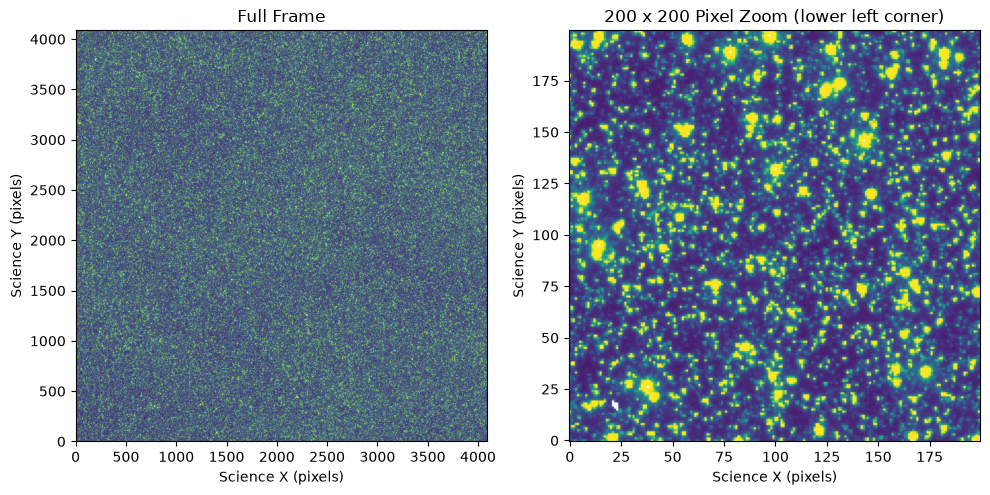

In [20]:
## If we know the name in advance, let's use it:
#root_path = 's3://stpubdata/roman/nexus/soc_simulations/r00340/l2/'
#asdf_file = 'r0034001002001001025_0001_wfi10_f146_cal.asdf'
#s3_uri = os.path.join(root_path, asdf_file)

# Otherwise, let's search for a file and pull the S3 URI from the results:
mask = (gbtds_manifest['detector'] == 'WFI10')
mask &= (gbtds_manifest['pass'] == 2)
mask &= (gbtds_manifest['visit'] == 25)
search_result = gbtds_manifest[mask]
s3_uri = search_result[0]['l2_s3_uri']

# Set up an S3 file system and stream the file into memory,
# then plot the image and a zoomed in 200x200 pixel area as well.
fs = s3fs.S3FileSystem(anon=True)
with fs.open(s3_uri, 'rb') as f:
    dm = rdm.open(f)
    fig, axs = plt.subplots(1, 2, figsize=(10, 6))

    # Normalization range chosen arbitrarily to show detail
    norm = simple_norm(dm.data, vmin=0.25, vmax=75)
    
    axs[0].imshow(dm.data, origin='lower', norm=norm)
    axs[0].set_xlabel('Science X (pixels)')
    axs[0].set_ylabel('Science Y (pixels)')
    axs[0].set_title('Full Frame')

    axs[1].imshow(dm.data[:200, :200], origin='lower', norm=norm)
    axs[1].set_xlabel('Science X (pixels)')
    axs[1].set_ylabel('Science Y (pixels)')
    axs[1].set_title('200 x 200 Pixel Zoom (lower left corner)')

    plt.tight_layout()

Let's also take a look at a HLWAS L3 product. Let's simply pull the first entry in the manifest file and plot it. We also plot the context image showing the overlapping of the input L2 products that were used to make this particular L3 mosaic.

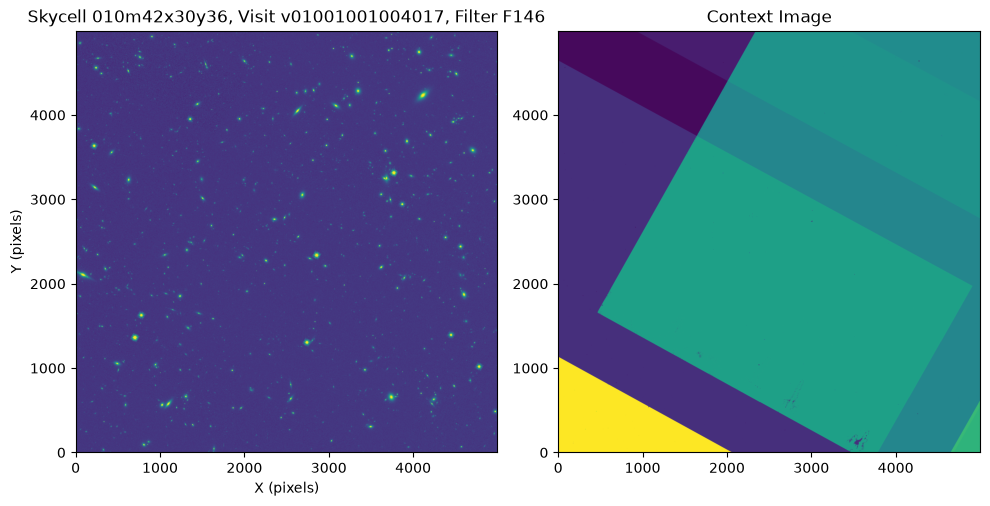

In [21]:
# Set up an S3 file system and stream the file into memory.
fs = s3fs.S3FileSystem(anon=True)
first_l3 = hlwas_coadd_manifest[0]
with fs.open(first_l3['l3_s3_uri'], 'rb') as f:
    dm = rdm.open(f)
    fig, axs = plt.subplots(1, 2, figsize=(10, 6))

    # Normalization chosen arbitrarily to show detail
    norm = simple_norm(dm.data, 'asinh', vmin=0.25, vmax=1)
    
    axs[0].imshow(dm.data, origin='lower', norm=norm)
    axs[0].set_xlabel('X (pixels)')
    axs[0].set_ylabel('Y (pixels)')
    axs[0].set_title(f'Skycell {first_l3['skycell_name']}, Visit {first_l3['grouping']}, Filter {first_l3['optical_element']}')

    # Also plot the context image
    axs[1].imshow(dm.context[0], origin='lower')
    axs[1].set_title('Context Image')
    
    plt.tight_layout()

### Accessing SOC Catalog Products

We can also stream SOC catalog products in Apache parquet format into memory and work with them. Here we show how to read such a file from S3 using the `pandas` package:

In [22]:
# If we know the name in advance, let's use it:
root_path = 's3://stpubdata/roman/nexus/soc_simulations/r00342/l4/l2_source_catalog/'
asdf_file = 'r0034201008001002018_0003_wfi01_f129_cat.parquet'
s3_uri = os.path.join(root_path, asdf_file)

fs = s3fs.S3FileSystem(anon=True)
with fs.open(s3_uri, 'rb') as f:
    df = pd.read_parquet(f)

df

,label,flagged_spatial_id,x_centroid,y_centroid,x_centroid_err,y_centroid_err,x_centroid_win,y_centroid_win,x_centroid_win_err,y_centroid_win_err,...,segment_flux,segment_flux_err,kron_flux,kron_flux_err,kron_abmag,kron_abmag_err,warning_flags,image_flags,psf_flags,psf_gof
0,1,0,1171.879639,8.583213,0.0,0.0,1171.355957,6.750168,0.0,0.0,...,109583.820312,247.241699,114146.960938,328.392365,18.756340,0.003119,0,0,1,616.170959
1,2,0,1796.517212,1.019734,0.0,0.0,1796.444092,1.330332,0.0,0.0,...,1381.295654,34.470608,2469.452148,63.939434,22.918499,0.027754,0,0,1,9.129353
2,3,0,2722.085693,11.600082,0.0,0.0,2722.333496,11.210129,0.0,0.0,...,11532.273438,95.553864,15076.641602,136.923355,20.954239,0.009816,0,0,1,44.048351
3,4,0,2997.037354,1.657626,0.0,0.0,2997.014648,1.408106,0.0,0.0,...,47921.171875,140.328445,47113.273438,135.252762,19.717142,0.003112,0,0,1,35.861645
4,5,0,3282.787109,14.380600,0.0,0.0,3283.447754,15.157268,0.0,0.0,...,188017.468750,286.744812,177074.203125,269.748138,18.279612,0.001653,0,0,0,96.097458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,883,0,515.874939,4076.204590,0.0,0.0,515.922058,4075.927490,0.0,0.0,...,11988.755859,87.199913,39277.421875,170.181732,19.914642,0.004694,0,0,1,68.978767
883,884,0,1515.296509,4073.138428,0.0,0.0,1514.821777,4072.904297,0.0,0.0,...,2207.150879,41.507526,4204.393555,83.066017,22.340740,0.021242,0,0,1,5.989530
884,885,0,2709.964600,4083.320801,0.0,0.0,2710.583496,4085.151367,0.0,0.0,...,66861.992188,215.760956,70010.250000,355.911682,19.287096,0.005506,0,0,1,413.956390
885,886,0,586.556641,4077.184326,0.0,0.0,586.800415,4076.963867,0.0,0.0,...,4069.494873,52.973125,13389.339844,109.439728,21.083103,0.008838,0,0,1,13.092576


We can also read in the file with the `pyarrow` package:

In [23]:
# If we know the name in advance, let's use it:
root_path = 's3://stpubdata/roman/nexus/soc_simulations/r00342/l4/l2_source_catalog/'
asdf_file = 'r0034201008001002018_0003_wfi01_f129_cat.parquet'
s3_uri = os.path.join(root_path, asdf_file)

fs = s3fs.S3FileSystem(anon=True)
with fs.open(s3_uri, 'rb') as f:
    cat = pa.parquet.read_table(f)

cat

pyarrow.Table
label: int32
flagged_spatial_id: int64
x_centroid: float
y_centroid: float
x_centroid_err: float
y_centroid_err: float
x_centroid_win: float
y_centroid_win: float
x_centroid_win_err: float
y_centroid_win_err: float
x_psf: float
x_psf_err: float
y_psf: float
y_psf_err: float
ra: double
dec: double
ra_centroid: double
dec_centroid: double
ra_centroid_err: float
dec_centroid_err: float
ra_centroid_win: double
dec_centroid_win: double
ra_centroid_win_err: float
dec_centroid_win_err: float
ra_psf: double
dec_psf: double
ra_psf_err: float
dec_psf_err: float
bbox_xmin: int32
bbox_xmax: int32
bbox_ymin: int32
bbox_ymax: int32
segment_area: float
semimajor: float
semiminor: float
fwhm: float
ellipticity: float
orientation_pix: float
orientation_sky: float
cxx: float
cxy: float
cyy: float
kron_radius: float
nn_label: int32
nn_distance: float
sharpness: float
roundness1: float
is_extended: bool
fluxfrac_radius_50: float
aper_bkg_flux: float
aper_bkg_flux_err: float
aper01_flux: floa

With the `pyarrow` package, we also have access to the metadata in the parquet file. Note that the metadata is flattened and returned as a dictionary with the keys as binary strings. For example, to access the `meta.exposure.start_time` value in the metadata, we need to use a string prefixed with the letter `b` as shown below:

In [24]:
print(cat.schema.metadata[b'roman.meta.exposure.start_time'])

b'2027-07-10T10:48:02.000'


We can also mark, e.g., all of the galaxies in an image that were detected in the source catalog. Let's take a look at an HLWAS L3 image and its catalog to do this. Note there are interactive tools, such as JDaviz, which also have this capability, but for consistency we will do this with matplotlib here.

/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.1.0' (from package roman_datamodels==0.30.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)


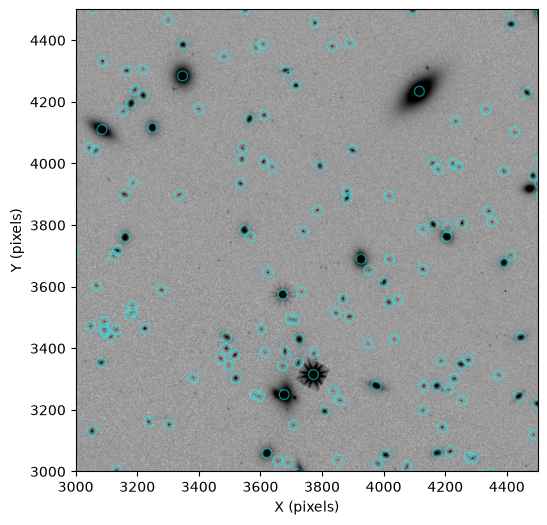

In [25]:
# Set up an S3 file system and stream the file into memory.
fs = s3fs.S3FileSystem(anon=True)
first_l3 = hlwas_coadd_manifest[0]
catalog = first_l3['l3_s3_uri'].replace('l3/', 'l4/l3_source_catalog/').replace('_coadd.asdf', '_cat.parquet')

# First open the catalog file and make a copy in memory.
with fs.open(catalog, 'rb') as f:
    df = pd.read_parquet(f).copy()

# Next open the image and plot the data array
with fs.open(first_l3['l3_s3_uri'], 'rb') as f:
    dm = rdm.open(f)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Normalization chosen arbitrarily to show detail
    norm = simple_norm(dm.data, 'asinh', vmin=0.25, vmax=0.5)

    ax.imshow(dm.data, origin='lower', norm=norm, cmap='gray_r')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

    # Identify galaxies from the is_extended column in the catalog
    df = df.loc[df.is_extended == True]

    # Overplot galaxies on the image
    ax.scatter(df.x_centroid, df.y_centroid, facecolors='none', edgecolors='cyan', s=50, lw=1, alpha=0.5)

    # Show a subsection of the image
    ax.set_xlim(3000, 4500)
    ax.set_ylim(3000, 4500)

As you can see, in the catalogs from this version of `romancal`, some bright stars have also been identified as extended sources. Improvements have been made to source classification since the simulated data products were created, so you may try making your own catalogs with a more recent version of `romancal`. See [Making GBTDS L4 Products](#making_catalogs) below for an example.

<a id='making_catalogs'></a>
#### Making GBTDS L4 Products

Note that L4 SOC products are not widely available for the GBTDS simulation. However, we can make them from the L2 files using `romancal`, which we do in the cell below.

**Note:** the following cell will take several minutes to execute. This will produce two files in your current working directory: 1) a source catalog `*_cat.parquet` file, and 2) a segmentation map `*_segm.asdf` file.

In [26]:
## If we know the name in advance, let's use it:
#root_path = 's3://stpubdata/roman/nexus/soc_simulations/r00340/l2/'
#asdf_file = 'r0034001002001001025_0001_wfi10_f146_cal.asdf'
#s3_uri = os.path.join(root_path, asdf_file)

# Otherwise, let's search for a file and pull the S3 URI from the results:
mask = (gbtds_manifest['detector'] == 'WFI10')
mask &= (gbtds_manifest['pass'] == 2)
mask &= (gbtds_manifest['visit'] == 25)
search_result = gbtds_manifest[mask]
s3_uri = search_result[0]['l2_s3_uri']

# Set up an S3 file system and stream the file into memory
fs = s3fs.S3FileSystem(anon=True)
with fs.open(s3_uri, 'rb') as f:
    dm = rdm.open(f)
    romancal.step.SourceCatalogStep.call(dm, update_version=True)

/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.1.0' (from package roman_datamodels==0.30.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)


2026-07-22 21:46:25,602 - stpipe.step - INFO - SourceCatalogStep instance created.


2026-07-22 21:46:26,121 - stpipe.step - INFO - Step SourceCatalogStep running with args (<roman_datamodels.datamodels._datamodels.ImageModel object at 0x7f3a027477e0>,).


2026-07-22 21:46:26,123 - stpipe.step - INFO - Step SourceCatalogStep parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: None
  output_ext: .asdf
  output_use_model: False
  output_use_index: True
  save_results: False
  skip: False
  suffix: cat
  search_output_file: True
  input_dir: ''
  update_version: True
  bkg_boxsize: 1000
  kernel_fwhm: 2.0
  snr_threshold: 3.0
  npixels: 25
  deblend: False
  fit_psf: True
  forced_segmentation: ''


2026-07-22 21:46:29,659 - py.warnings - WARNING - /home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/romancal/datamodels/fileio.py:69: MigrationWarning: Migration is adding keyword hga_move to the exposure block and arbitrarily setting it to False.
  result = update_model_version(dataset)



...

2026-07-22 21:54:01,547 - romancal.source_catalog._source_catalog - WARNING - meta.wcsinfo missing skycell_name/pixel_scale_ref; flagged_spatial_id will be zero.


2026-07-22 21:54:02,147 - stpipe.step - INFO - Saved model in r0034001002001015025_0001_wfi10_f146_segm.asdf


2026-07-22 21:54:02,718 - stpipe.step - INFO - Saved model in r0034001002001015025_0001_wfi10_f146_cat.parquet


2026-07-22 21:54:03,291 - romancal.stpipe.core - INFO - Results used CRDS context: roman_0058.pmap


2026-07-22 21:54:03,292 - stpipe.step - INFO - Step SourceCatalogStep done


Now let's open the catalog file and take a look:

In [27]:
gbtds_cat = pd.read_parquet(os.path.basename(search_result[0]['l2_s3_uri']).replace('_cal.asdf', '_cat.parquet'))
gbtds_cat

,label,flagged_spatial_id,x_centroid,y_centroid,x_centroid_err,y_centroid_err,x_centroid_win,y_centroid_win,x_centroid_win_err,y_centroid_win_err,...,segment_flux_err,kron_flux,kron_flux_err,kron_abmag,kron_abmag_err,warning_flags,image_flags,psf_flags,psf_gof,dust_ebv
0,1,0,20.724205,1.759928,0.0,0.0,20.875845,1.314916,0.0,0.0,...,1598.632202,7.674439e+05,1596.995361,16.687384,0.002257,0,0,0,1376.645508,1.321356
1,2,0,41.073574,3.210489,0.0,0.0,40.324703,3.037090,0.0,0.0,...,310.052734,1.503112e+05,461.452667,18.457521,0.003328,0,0,0,1393.673584,1.322209
2,3,0,167.017059,2.159441,0.0,0.0,167.039474,2.111706,0.0,0.0,...,1149.919922,4.945273e+05,1153.872803,17.164524,0.002530,0,0,0,1005.412354,1.327222
3,4,0,198.063843,0.899025,0.0,0.0,198.017502,0.145077,0.0,0.0,...,1297.992432,5.368336e+05,1298.069702,17.075401,0.002622,0,0,1,3567.332275,1.328343
4,5,0,210.065674,2.709198,0.0,0.0,210.583160,2.146039,0.0,0.0,...,1990.789062,1.253287e+06,1992.381104,16.154873,0.001725,0,0,0,5437.518066,1.328740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38062,38063,0,2481.352295,4085.832764,0.0,0.0,2481.105957,4086.499268,0.0,0.0,...,2314.165283,1.282857e+06,2313.438965,16.129555,0.001956,0,0,1,1510.198120,1.367353
38063,38064,0,3533.310547,4085.869629,0.0,0.0,3534.827148,4086.044922,0.0,0.0,...,443.522064,4.386967e+05,616.066895,17.294590,0.001524,0,0,1,9117.288086,1.474364
38064,38065,0,3653.106689,4085.205566,0.0,0.0,3652.826416,4085.217285,0.0,0.0,...,251.165894,1.635395e+05,423.409882,18.365944,0.002807,0,0,0,5233.841309,1.485824
38065,38066,0,3854.058594,4085.332275,0.0,0.0,3854.059326,4085.684082,0.0,0.0,...,1670.910034,8.348259e+05,1672.681519,16.596010,0.002173,0,0,0,1822.084839,1.503953


We can see that the catalog in this example detected 38,067 sources, which is much fewer than the number of sources actually in the image (usually several million stars per detector). This is because the `romancal` source cataloging code is not designed for crowded fields at present.

<a id="correcting_gbtds"></a>
### Correcting GBTDS Simulation WCS

As mentioned in [Simulation Settings and Caveats](#gbtds_caveats) section of the GBTDS description above, the GBTDS L2 WCS is incorrect in the files on S3. Since Roman I-Sim simulates images with perfect pointings, we can recover the correct WCS by retrieving the information from the corresponding L1 file, updating the metadata of the L2 datamodel in memory, and re-running the Assign WCS step of the Exposure Level Pipeline (ELP) to re-generate the `gwcs` object in the datamodel. We have provided a script (in `fix_gbtds_wcs.py`) for quickly reading the corresponding L1 file metadata and doing this operation for you:

In [28]:
## If we know the name in advance, let's use it:
#root_path = 's3://stpubdata/roman/nexus/soc_simulations/r00340/l2/'
#asdf_file = 'r0034001002001001025_0001_wfi10_f146_cal.asdf'
#s3_uri = os.path.join(root_path, asdf_file)

# Otherwise, let's search for a file and pull the S3 URI from the results:
mask = (gbtds_manifest['detector'] == 'WFI10')
mask &= (gbtds_manifest['pass'] == 2)
mask &= (gbtds_manifest['visit'] == 25)
search_result = gbtds_manifest[mask]
s3_uri = search_result[0]['l2_s3_uri']

## Provide an S3 URI as input to read the file and update it in memory:
# dm_update = update_wcs(os.path.join(root_path, asdf_file))

## Open a file on disk and update it in memory:
# dm_update = update_wcs(asdf_file)

# Stream the file into memory first, then update in-place.
# (to optionally save a copy to local storage, uncomment the update_dm.save() line)
fs = s3fs.S3FileSystem(anon=True)
with fs.open(s3_uri, 'rb') as f:
    dm = rdm.open(f)
    update_dm = update_wcs(dm.copy())
    # update_dm.save(f"{asdf_file.replace('_cal.asdf', '_fixwcs_cal.asdf')}")

# Compute the sky position at the center of the detector
old = dm.meta.wcs(2043.5, 2043.5)
new = update_dm.meta.wcs(2043.5, 2043.5)

# Print the results
print(f'Wrong coordinates = ({old[0]:.5f}, {old[1]:.5f})')
print(f'Corrected coordinates = ({new[0]:.5f}, {new[1]:.5f})')

# Make SkyCoord objects of the old and new celestial positions and 
# compute the separation
old_cdt = SkyCoord(*old, unit='deg')
new_cdt = SkyCoord(*new, unit='deg')
print(f'Separation = {old_cdt.separation(new_cdt).to(u.arcsec):.3f}')

/home/runner/micromamba/envs/ci-env/lib/python3.12/site-packages/asdf/_asdf.py:274: AsdfPackageVersionWarning: File was created with extension URI 'asdf://stsci.edu/datamodels/roman/extensions/static-1.1.0' (from package roman_datamodels==0.30.0), which is not currently installed
  warnings.warn(msg, AsdfPackageVersionWarning)


2026-07-22 21:54:06,229 - stpipe.step - INFO - AssignWcsStep instance created.


2026-07-22 21:54:06,794 - stpipe.step - INFO - Step AssignWcsStep running with args (<roman_datamodels.datamodels._datamodels.ImageModel object at 0x7f3a021f1ee0>,).


2026-07-22 21:54:06,796 - stpipe.step - INFO - Step AssignWcsStep parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir: None
  output_ext: .asdf
  output_use_model: False
  output_use_index: True
  save_results: False
  skip: False
  suffix: None
  search_output_file: True
  input_dir: ''
  update_version: False


2026-07-22 21:54:06,796 - romancal.assign_wcs.assign_wcs_step - INFO - reftype, distortion


...

2026-07-22 21:54:06,858 - romancal.assign_wcs.assign_wcs - INFO - S_REGION VALUES: POLYGON ICRS  267.717554764 -30.004495689 267.790241511 -29.898981041 267.665309326 -29.835437207 267.593145595 -29.941290701


2026-07-22 21:54:06,858 - romancal.assign_wcs.assign_wcs - INFO - Update S_REGION to POLYGON ICRS  267.717554764 -30.004495689 267.790241511 -29.898981041 267.665309326 -29.835437207 267.593145595 -29.941290701


2026-07-22 21:54:08,633 - romancal.stpipe.core - INFO - Results used CRDS context: roman_0058.pmap


2026-07-22 21:54:08,634 - stpipe.step - INFO - Step AssignWcsStep done


Wrong coordinates = (267.69055, -29.92081)
Corrected coordinates = (267.69142, -29.92037)
Separation = 3.143 arcsec


## What's Next

TBD

## Additional Resources

- The [Roman Help Desk](https://romanhelp.stsci.edu)

***

## About this Notebook

**Authors:** Tyler Desjardins\
**Update Overview:** 2026-07-13, First created.

<table width="100%" style="border:none; border-collapse:collapse;">


  <tr style="border:none;">
    <td style="border:none; width:180px; white-space:nowrap;">
       <a href="#top" style="text-decoration:none; color:#0066cc;"> Top of page</a>
    </td>
    <td style="border:none; text-align:center;">
        <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/roman_logo.png" alt="roman_logo" width="50px">
    </td>
    <td style="border:none; text-align:right;">
       <img src="https://raw.githubusercontent.com/spacetelescope/roman_notebooks/refs/heads/main/stsci_logo2.png" width="90">
    </td>
  </tr>
</table>